# Prophet with load lags and weather

This notebook uses a flat baseline trend with daily, weekly, and yearly seasonality, plus load and weather regressors. The flat trend prevents an extrapolated long-term decline from overwhelming the recent load information in the regressors.

Run all cells from a fresh kernel after changing the model so forecasts, metrics, plots, and component summaries describe the same fit.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

Importing plotly failed. Interactive plots will not work.


In [2]:
DATA_PATH = Path("../data/processed/sardinia_hourly.parquet")
df = pd.read_parquet(DATA_PATH)

df.head()

,Total Load [MW],Forecast Total Load [MW]
Date,,
2023-01-01 00:00:00+01:00,806.13675,833.01000
2023-01-01 01:00:00+01:00,783.55525,779.20525
2023-01-01 02:00:00+01:00,753.62675,749.15025
2023-01-01 03:00:00+01:00,736.34950,739.18250
2023-01-01 04:00:00+01:00,723.29950,749.01150


In [3]:
weather = pd.read_parquet(
    "../data/processed/sardinia_weather_hourly.parquet"
).copy()

weather.index = (
    weather.index
    .tz_convert("UTC")
    .tz_localize(None)
)

weather = (
    weather
    .reset_index()
    .rename(columns={"Date": "ds"})
)

weather = weather.rename(columns={"time": "ds"})
weather.head()

,ds,temperature_weighted,humidity_weighted,cloud_cover_weighted,temperature_min,temperature_max
0,2024-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN
1,2024-01-01 01:00:00,NaN,NaN,NaN,NaN,NaN
2,2024-01-01 02:00:00,NaN,NaN,NaN,NaN,NaN
3,2024-01-01 03:00:00,NaN,NaN,NaN,NaN,NaN
4,2024-01-01 04:00:00,NaN,NaN,NaN,NaN,NaN


In [4]:
prophet_df = (
    df[["Total Load [MW]"]]
    .rename(columns={"Total Load [MW]": "y"})
    .copy()
)

prophet_df["lag_24h"] = prophet_df["y"].shift(24)
prophet_df["lag_168h"] = prophet_df["y"].shift(168)

# Prophet requires timezone-naive timestamps.
# UTC avoids duplicated timestamps during DST transitions.
prophet_df.index = (
    prophet_df.index
    .tz_convert("UTC")
    .tz_localize(None)
)

prophet_df = (
    prophet_df
    .reset_index()
    .rename(columns={"Date": "ds"})
)

prophet_df.head()

,ds,y,lag_24h,lag_168h
0,2022-12-31 23:00:00,806.13675,NaN,NaN
1,2023-01-01 00:00:00,783.55525,NaN,NaN
2,2023-01-01 01:00:00,753.62675,NaN,NaN
3,2023-01-01 02:00:00,736.34950,NaN,NaN
4,2023-01-01 03:00:00,723.29950,NaN,NaN


In [5]:
weather_features = [
    "temperature_weighted",
    "humidity_weighted",
    "cloud_cover_weighted",
    "temperature_min",
    "temperature_max",
]

prophet_weather = prophet_df.merge(
    weather[["ds"] + weather_features],
    on="ds",
    how="left",
)

prophet_weather[
    ["y", "lag_24h", "lag_168h"] + weather_features
].isna().sum()

y                         48
lag_24h                   72
lag_168h                 216
temperature_weighted    9205
humidity_weighted       9205
cloud_cover_weighted    9205
temperature_min         9205
temperature_max         9205
dtype: int64

## Training coverage and fair comparisons

Complete-case filtering for weather removes the load history before January 19, 2024. Adding weather therefore also changes the training period. To isolate the effect of weather, compare models trained on the same complete-case rows and evaluated on identical timestamps.

The cutoff below is January 1, 2026 at midnight in Europe/Rome, expressed as naive UTC. Both load and weather timestamps use that convention before merging.


In [6]:
required_columns = [
    "y",
    "lag_24h",
    "lag_168h",
] + weather_features

prophet_weather_clean = (
    prophet_weather
    .dropna(subset=required_columns)
    .copy()
)

train_prophet_weather = prophet_weather_clean[
    prophet_weather_clean["ds"] < "2025-12-31 23:00:00"
].copy()

test_prophet_weather = prophet_weather_clean[
    prophet_weather_clean["ds"] >= "2025-12-31 23:00:00"
].copy()

print(f"Train: {len(train_prophet_weather):,}")
print(f"Test:  {len(test_prophet_weather):,}")

print(
    "Train:",
    train_prophet_weather["ds"].min(),
    "->",
    train_prophet_weather["ds"].max(),
)

print(
    "Test:",
    test_prophet_weather["ds"].min(),
    "->",
    test_prophet_weather["ds"].max(),
)

Train: 17,099
Test:  6,551
Train: 2024-01-19 12:00:00 -> 2025-12-31 22:00:00
Test: 2025-12-31 23:00:00 -> 2026-10-05 21:00:00


## Why use a flat trend?

Diagnostic reruns on the same 6,551 test observations gave:

| Configuration | MAPE |
|---|---:|
| Load lags, full training history, linear trend | 5.31% |
| Load lags, weather-available training rows, linear trend | 10.95% |
| Load lags and weather, linear trend | 11.84% |
| Load lags and weather, flat trend | 3.53% |
| Load lags and weather, linear trend without yearly seasonality | 4.30% |

These are recorded diagnostic results, not a validation-based model search. The shorter-history weather model extrapolated a trend from about 911 to 805 MW through the test period and underpredicted load by about 121 MW on average. Most of the deterioration was already present without weather on the shorter training history.

`growth="flat"` holds the trend constant; seasonalities and regressors still vary the prediction. See [Prophet's flat-trend documentation](https://facebook.github.io/prophet/docs/additional_topics.html#flat-trend).

Yearly seasonality remains enabled, so the warning about less than two years of training history still applies. Flat growth addresses trend extrapolation, not all uncertainty in the seasonal decomposition. Since the 2026 results informed this change, treat them as exploratory; compare configurations on a chronological validation period within the pre-2026 training data before making a final model choice.


In [7]:
model_weather = Prophet(
    # Avoid extrapolating the declining trend fitted on the shorter weather history.
    growth="flat",
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True,
)

regressors = [
    "lag_24h",
    "lag_168h",
    "temperature_weighted",
    "humidity_weighted",
    "cloud_cover_weighted",
    "temperature_min",
    "temperature_max",
]

for regressor in regressors:
    model_weather.add_regressor(regressor)

model_weather.fit(
    train_prophet_weather[
        ["ds", "y"] + regressors
    ]
)

/Users/aserra/miniforge3/envs/timeseries/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Yearly seasonality is enabled with less than 730 days (approximately 2 years) of history. The model may be under-identified, and the trend/seasonality decomposition can be unstable and dependent on the Prophet/Stan version. Consider disabling yearly seasonality or providing more history.
13:23:33 - cmdstanpy - INFO - Chain [1] start processing
13:23:33 - cmdstanpy - INFO - Chain [1] done processing


In [8]:
future = test_prophet_weather[
    ["ds"] + regressors
].copy()

forecast = model_weather.predict(future)

results_prophet = (
    test_prophet_weather[["ds", "y"]]
    .merge(
        forecast[["ds", "yhat"]],
        on="ds",
        how="inner",
    )
)

results_prophet.head()

,ds,y,yhat
0,2025-12-31 23:00:00,809.42325,802.945111
1,2026-01-01 00:00:00,774.35375,759.627070
2,2026-01-01 01:00:00,740.69925,732.631029
3,2026-01-01 02:00:00,716.15600,716.033814
4,2026-01-01 03:00:00,706.16175,724.614540


In [9]:
mae = mean_absolute_error(
    results_prophet["y"],
    results_prophet["yhat"],
)

rmse = np.sqrt(
    mean_squared_error(
        results_prophet["y"],
        results_prophet["yhat"],
    )
)

mape = mean_absolute_percentage_error(
        results_prophet["y"],
        results_prophet["yhat"],
    ) * 100

print(f"MAE:  {mae:.2f} MW")
print(f"RMSE: {rmse:.2f} MW")
print(f"MAPE: {mape:.2f}%")

MAE:  36.72 MW
RMSE: 50.30 MW
MAPE: 3.53%


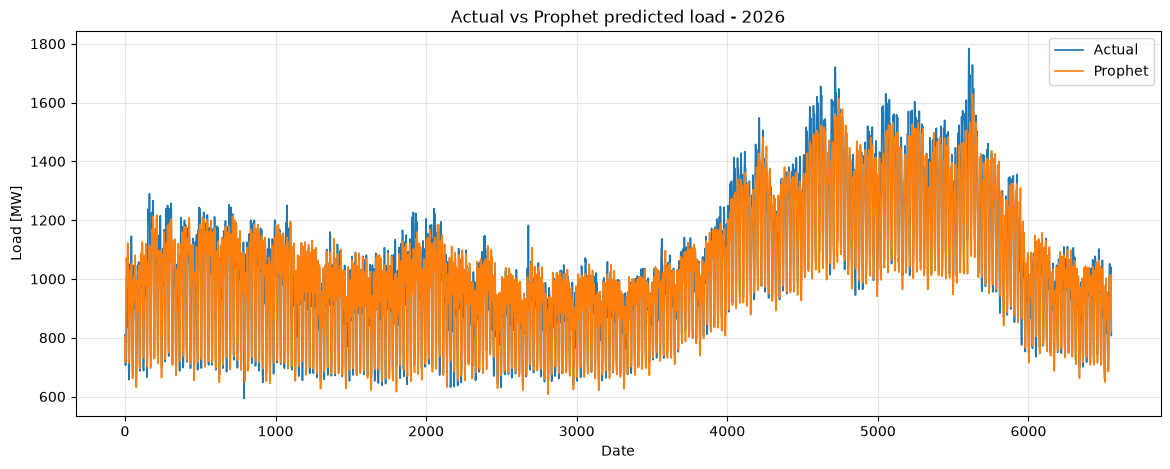

In [16]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    results_prophet.index,
    results_prophet["y"],
    label="Actual",
    linewidth=1.2,
)

ax.plot(
    results_prophet.index,
    results_prophet["yhat"],
    label="Prophet",
    linewidth=1.2,
)

ax.set_title("Actual vs Prophet predicted load - 2026")
ax.set_xlabel("Date")
ax.set_ylabel("Load [MW]")
ax.legend()
ax.grid(alpha=0.3)

plt.show()

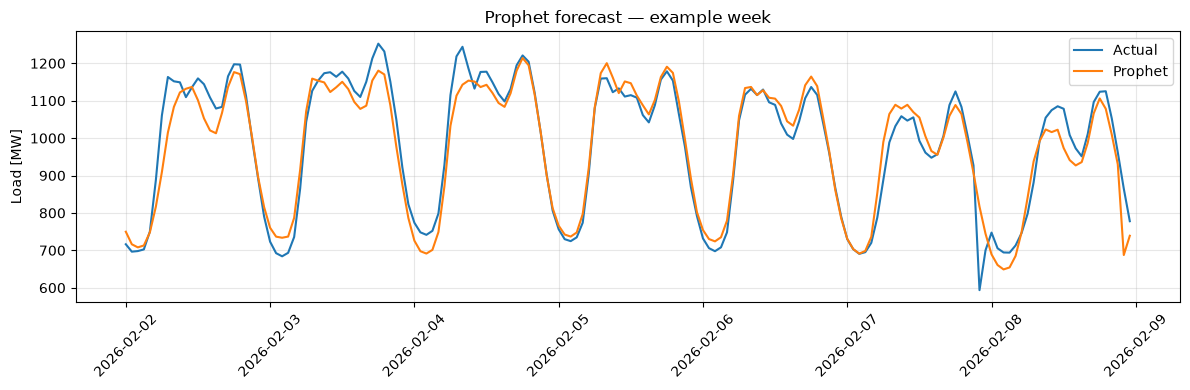

In [10]:
week = results_prophet[
    (results_prophet["ds"] >= "2026-02-02") &
    (results_prophet["ds"] < "2026-02-09")
]

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(week["ds"], week["y"], label="Actual")
ax.plot(week["ds"], week["yhat"], label="Prophet")

ax.set_ylabel("Load [MW]")
ax.set_title("Prophet forecast — example week")
ax.legend()
ax.grid(alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Check the fitted components

With flat growth, the forecast trend should remain constant across the test period. This summary is recomputed from the same forecast used for the metrics above.


In [11]:
forecast[
    ["trend", "daily", "weekly", "yearly", "yhat"]
].describe()

,trend,daily,weekly,yearly,yhat
count,6.551000e+03,6551.000000,6551.000000,6551.000000,6551.000000
mean,9.585152e+02,0.003010,-0.099503,1.933248,1018.104706
std,1.136955e-13,21.435226,23.543218,14.070881,210.163257
min,9.585152e+02,-37.708232,-46.662306,-23.025014,607.983516
25%,9.585152e+02,-22.063906,-10.503282,-7.846529,879.962194
50%,9.585152e+02,7.808411,1.487731,0.441590,1006.022244
75%,9.585152e+02,18.678411,6.687696,12.416342,1125.023250
max,9.585152e+02,23.230471,44.245492,29.732329,1628.432467


## Training versus test error

Training error is an in-sample diagnostic, not chronological validation. The test evaluation uses observed historical load lags at each target timestamp; it does not represent a single multi-month forecast issued at the training cutoff. For an operational day-ahead forecast, lag availability must also match the actual issue time.


In [12]:
train_future = train_prophet_weather[
    ["ds"] + regressors
].copy()

train_forecast = model_weather.predict(train_future)

train_results = (
    train_prophet_weather[["ds", "y"]]
    .merge(
        train_forecast[["ds", "yhat"]],
        on="ds",
        how="inner",
    )
)

train_mae = mean_absolute_error(
    train_results["y"],
    train_results["yhat"],
)

test_mae = mean_absolute_error(
    results_prophet["y"],
    results_prophet["yhat"],
)

print(f"Train MAE: {train_mae:.2f} MW")
print(f"Test MAE:  {test_mae:.2f} MW")

Train MAE: 34.13 MW
Test MAE:  36.72 MW
